# BỘ ĐIỀU HƯỚNG LÔ-GÍC (LOGIC ROUTER) & 5 SIÊU HÀNH ĐỘNG CẤU TRÚC (MACRO-ACTIONS)
## Thiết Kế Kiến Trúc Thích Ứng (Adaptive QNN Architecture) Với Plot Động Trực Quan Chậm Rãi & Màu Sắc Tươi Sáng

---

### TỔNG QUAN HỆ THỐNG
Trong các Mạng Nơ-ron Lượng tử Tham số hóa (Parameterized Quantum Circuits - PQC), việc cố định độ sâu tĩnh $D(t) = 	ext{const}$ dẫn đến hai nghịch lý đối nghịch:
1. **Mạch nông ($D \le 2$)**: Thiếu dung lượng biểu diễn (Expressibility deficit) $\implies$ Kẹt tại vùng bằng phẳng cục bộ Underfitting.
2. **Mạch sâu ($D \ge 8$)**: Không gian Hilbert quá lớn dẫn đến ngẫu nhiên hóa trạng thái Haar $\implies$ Rơi vào thảm họa **Barren Plateau** (Gradient triệt tiêu theo hàm mũ $\mathcal{O}(2^{-n})$) và tích lũy nhiễu mất pha vật lý ($T_1, T_2$ decoherence).

Để giải quyết triệt để vấn đề này, **Phương pháp 2: Điều Khiển Độ Sâu Mạch Thích Ứng (Adaptive Depth Control)** tổ chức quá trình tối ưu hóa xoay quanh:
* **Bộ Điều Hướng Lô-Gíc (Logic Router)**: Đóng vai trò như một **Lớp Bảo Vệ Xác Định (Deterministic Safety Guardrail)** dựa trên 6 luồng tín hiệu đo đạc từ xa (Real-Time Telemetry) để điều tiết độ sâu $D(t)$ linh hoạt.
* **5 Siêu Hành Động Cấu Trúc (5 Macro-Actions)**: Gồm `ADD_LAYER`, `KEEP`, `FREEZE`, `PROPOSE_PRUNE`, và `STOP_GROWTH`.

> **Đặc điểm hiển thị & Hoạt họa chậm rãi (Educational Slow-Paced Animation)**:
> * **Tốc độ trình chiếu chậm rãi (~300–400ms / khung hình, tổng thời lượng ~10–12 giây / animation)**: Giúp người xem dễ dàng quan sát hạt tối ưu hóa di chuyển, đọc từng dòng chỉ số trên bảng đồng hồ Telemetry HUD, và nhận diện rõ ràng thời điểm hành động được kích hoạt.
> * **Bảng màu tươi sáng, sắc nét chuẩn ấn phẩm khoa học (Bright Modern Scientific Palette)**: Nền trắng tinh khiết (`#FFFFFF`), lưới mờ nhẹ (`#E2E8F0`), chữ than đậm tương phản cao (`#0F172A`), kết hợp dải màu sống động (Electric Blue `#0284C7`, Emerald Green `#059669`, Coral Red `#EF4444`, Vibrant Violet `#8B5CF6`, Amber Gold `#F59E0B`).
> * **Điều khiển linh hoạt**: Bấm **`▶ Play Simulation`** để xem hoạt họa tự chạy chậm rãi; bấm **`⏸ Pause`** để tạm dừng; hoặc kéo thanh trượt **`Slider`** bên dưới để soi kỹ từng Epoch/Step cụ thể.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

os.makedirs('figures', exist_ok=True)

# Bright Modern Scientific Palette
LIGHT_BG = "#FFFFFF"
PANEL_BG = "#FAFAFA"
GRID_COLOR = "#E2E8F0"
BORDER_COLOR = "#CBD5E1"
TEXT_COLOR = "#0F172A"
SUBTEXT_COLOR = "#475569"

print("Setup completed. Bright Modern Scientific Telemetry toolkit ready.")

Setup completed. Bright Modern Scientific Telemetry toolkit ready.


---
## PHẦN 1: BỘ ĐIỀU HƯỚNG LÔ-GÍC (LOGIC ROUTER ARCHITECTURE)

Bộ điều hướng lô-gíc giám sát liên tục trạng thái lượng tử thông qua 6 tín hiệu đo đạc từ xa (Telemetry Signals):
1. **$\Delta \mathcal{L}$ (Loss Velocity)**: Vận tốc suy giảm hàm mất mát qua cửa sổ trượt $k$ chu kỳ.
2. **$\|
abla \mathcal{L}\|$ (Global Gradient Norm)**: Chuẩn độ dốc toàn cục đánh giá độ dốc bề mặt Loss.
3. **$\|
abla_l \mathcal{L}\|$ (Layer-wise Gradient Norm)**: Chuẩn đạo hàm riêng của từng tầng $l \in \{1, \dots, D(t)\}$.
4. **$p_{L_j}$ (Dead Layer Probability)**: Điểm số xác suất dư thừa / không đóng góp của tầng $j$.
5. **$\operatorname{Var}(
abla \mathcal{L})$ (Gradient Variance)**: Thước đo nguy cơ rơi vào vùng phẳng lì Barren Plateau.
6. **$D(t), D_{\max}$ (Circuit Depth State)**: Độ sâu hiện tại so với giới hạn trần an toàn.

#### Thứ tự phân xử ưu tiên an toàn phân cấp (Hierarchical Arbitration Rules):
$$	ext{Action}(t) = egin{cases} 
\mathbf{STOP\_GROWTH} & 	ext{nếu } \operatorname{Var}[
abla \mathcal{L}] < \epsilon_{	ext{BP}} \quad (	ext{Ưu tiên 1: An toàn tối thượng, chặn Barren Plateau}) \
\mathbf{PROPOSE\_PRUNE} & 	ext{nếu } \exists j: p_{L_j} > 0.85 \quad (	ext{Ưu tiên 2: Cắt tầng chết, giảm nhiễu vật lý } T_1, T_2) \
\mathbf{FREEZE} & 	ext{nếu } \exists l: \|
abla_l \mathcal{L}\| < \epsilon_{	ext{freeze}} \quad (	ext{Ưu tiên 3: Tiết kiệm số lần đo Parameter-Shift}) \
\mathbf{ADD\_LAYER} & 	ext{nếu } \Delta \mathcal{L} \ge 0 \land \|
abla \mathcal{L}\| > \epsilon_{	ext{healthy}} \land D < D_{\max} \quad (	ext{Ưu tiên 4: Mở rộng không gian Hilbert}) \
\mathbf{KEEP} & 	ext{nếu } \Delta \mathcal{L} < 0 \quad (	ext{Mặc định: Duy trì hành lang tối ưu hóa})
\end{cases}$$

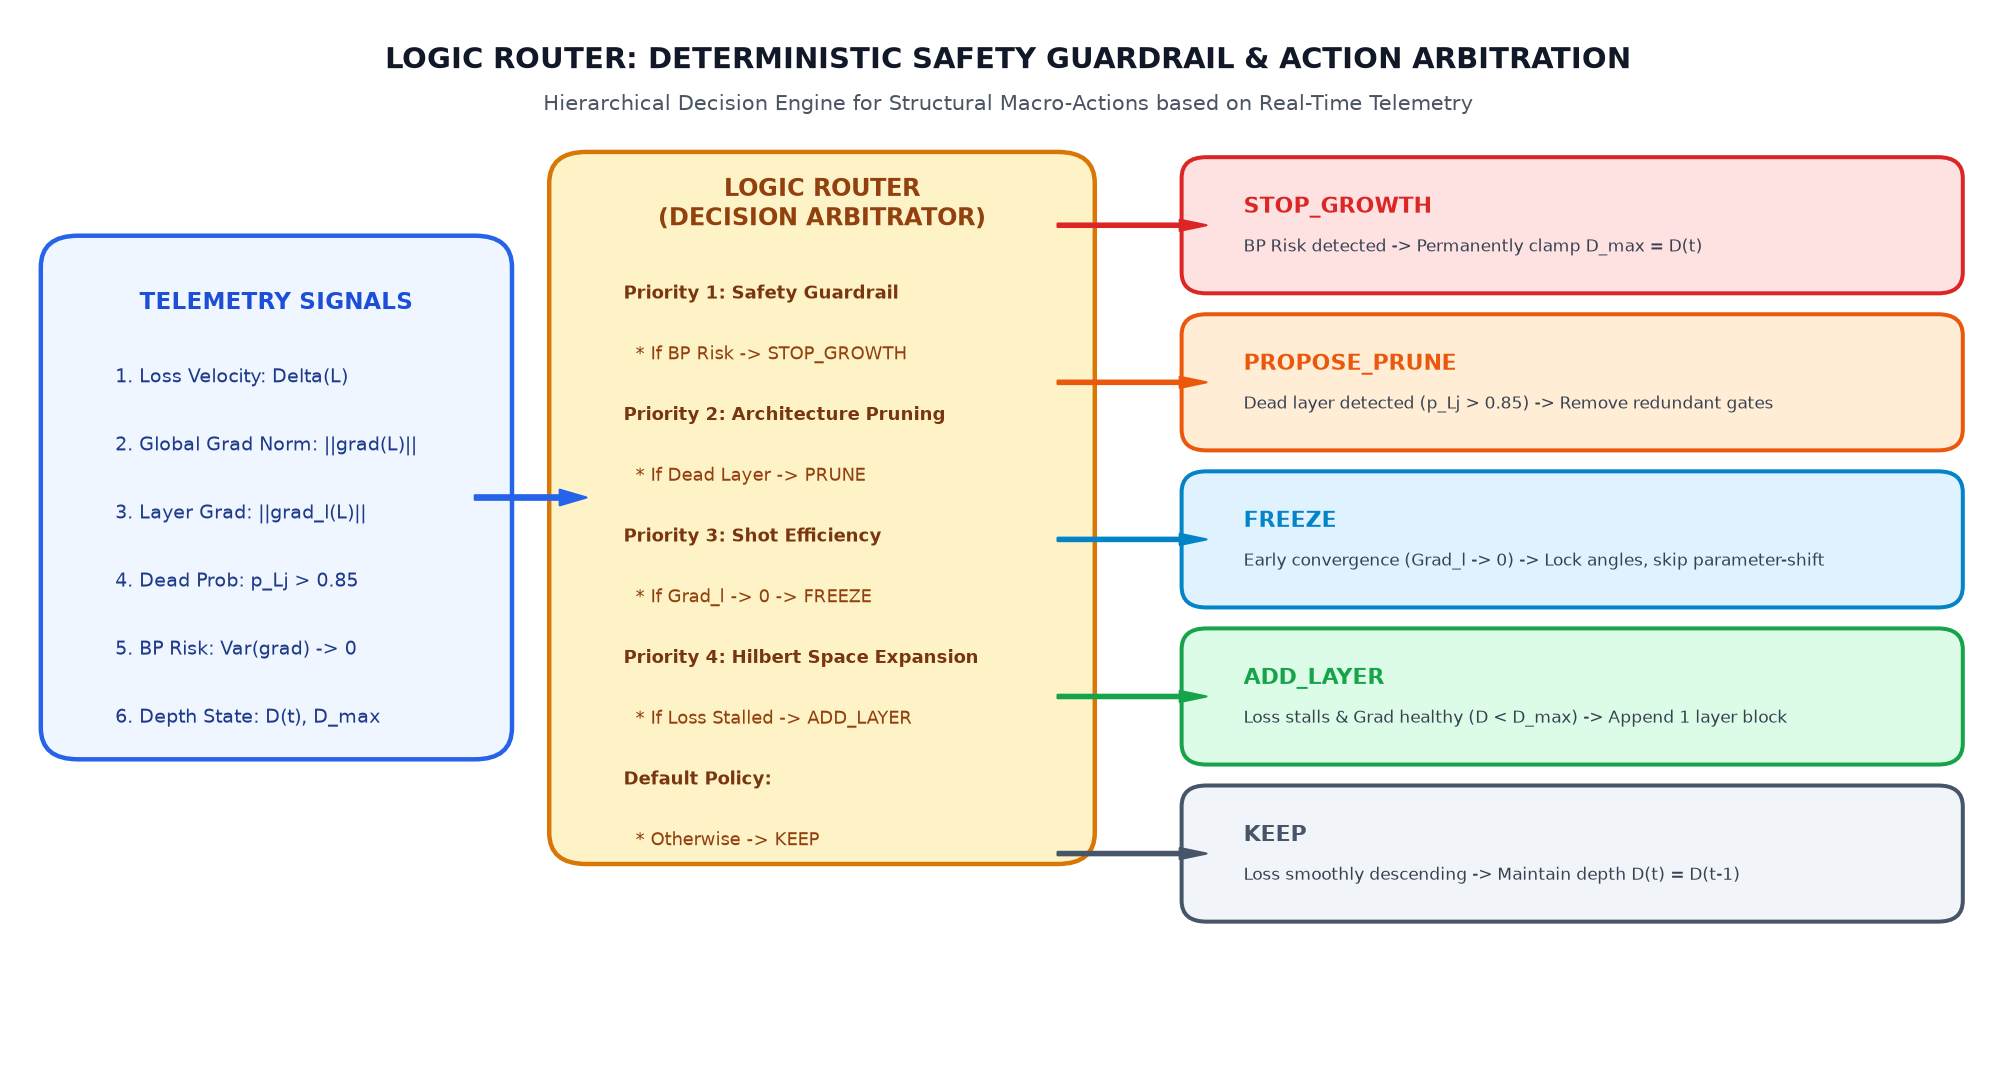

In [2]:
# Hiển thị sơ đồ kiến trúc Bộ Điều Hướng Lô-Gíc (Logic Router Flowchart)
fig, ax = plt.subplots(figsize=(16, 8.5), dpi=160)
ax.set_xlim(0, 16); ax.set_ylim(0, 10); ax.axis('off')

# Title
ax.text(8.0, 9.5, "LOGIC ROUTER: DETERMINISTIC SAFETY GUARDRAIL & ACTION ARBITRATION", 
        fontsize=13, fontweight='bold', color='#111827', ha='center')
ax.text(8.0, 9.1, "Hierarchical Decision Engine for Structural Macro-Actions based on Real-Time Telemetry", 
        fontsize=9.5, color='#4B5563', ha='center')

# Input Telemetry Box (Fresh Soft Blue)
telemetry_box = FancyBboxPatch((0.5, 3.2), 3.2, 4.4, boxstyle="round,pad=0.3", fc="#EFF6FF", ec="#2563EB", lw=2)
ax.add_patch(telemetry_box)
ax.text(2.1, 7.2, "TELEMETRY SIGNALS", fontsize=10.5, fontweight='bold', color="#1D4ED8", ha='center')
signals = [
    "1. Loss Velocity: Delta(L)",
    "2. Global Grad Norm: ||grad(L)||",
    "3. Layer Grad: ||grad_l(L)||",
    "4. Dead Prob: p_Lj > 0.85",
    "5. BP Risk: Var(grad) -> 0",
    "6. Depth State: D(t), D_max"
]
for idx, s in enumerate(signals):
    ax.text(0.8, 6.5 - idx*0.65, s, fontsize=8.5, color="#1E3A8A")

# Arrow to Router
ax.annotate('', xy=(4.6, 5.4), xytext=(3.7, 5.4),
            arrowprops=dict(facecolor='#2563EB', edgecolor='#2563EB', width=2, headwidth=7))

# Central Logic Router Box (Fresh Soft Amber)
router_box = FancyBboxPatch((4.6, 2.2), 3.8, 6.2, boxstyle="round,pad=0.3", fc="#FEF3C7", ec="#D97706", lw=2)
ax.add_patch(router_box)
ax.text(6.5, 8.0, "LOGIC ROUTER\n(DECISION ARBITRATOR)", fontsize=11, fontweight='bold', color="#92400E", ha='center')
router_rules = [
    "Priority 1: Safety Guardrail",
    "  * If BP Risk -> STOP_GROWTH",
    "Priority 2: Architecture Pruning",
    "  * If Dead Layer -> PRUNE",
    "Priority 3: Shot Efficiency",
    "  * If Grad_l -> 0 -> FREEZE",
    "Priority 4: Hilbert Space Expansion",
    "  * If Loss Stalled -> ADD_LAYER",
    "Default Policy:",
    "  * Otherwise -> KEEP"
]
for idx, r in enumerate(router_rules):
    fontw = 'bold' if 'Priority' in r or 'Default' in r else 'normal'
    col = '#78350F' if fontw == 'bold' else '#92400E'
    ax.text(4.9, 7.3 - idx*0.58, r, fontsize=8, fontweight=fontw, color=col)

# 5 Action Output Boxes (Fresh High-Contrast Colors)
actions_info = [
    ("STOP_GROWTH", "#FEE2E2", "#DC2626", 8.0, "BP Risk detected -> Permanently clamp D_max = D(t)"),
    ("PROPOSE_PRUNE", "#FFEDD5", "#EA580C", 6.5, "Dead layer detected (p_Lj > 0.85) -> Remove redundant gates"),
    ("FREEZE", "#E0F2FE", "#0284C7", 5.0, "Early convergence (Grad_l -> 0) -> Lock angles, skip parameter-shift"),
    ("ADD_LAYER", "#DCFCE7", "#16A34A", 3.5, "Loss stalls & Grad healthy (D < D_max) -> Append 1 layer block"),
    ("KEEP", "#F1F5F9", "#475569", 2.0, "Loss smoothly descending -> Maintain depth D(t) = D(t-1)")
]

for name, bg_col, border_col, y_pos, desc in actions_info:
    card = FancyBboxPatch((9.6, y_pos - 0.45), 5.9, 0.9, boxstyle="round,pad=0.2", fc=bg_col, ec=border_col, lw=1.8)
    ax.add_patch(card)
    ax.text(9.9, y_pos + 0.12, name, fontsize=10, fontweight='bold', color=border_col)
    ax.text(9.9, y_pos - 0.25, desc, fontsize=7.5, color='#374151')
    ax.annotate('', xy=(9.6, y_pos), xytext=(8.4, y_pos),
                arrowprops=dict(facecolor=border_col, edgecolor=border_col, width=1.5, headwidth=5))

fig.savefig("figures/fig_logic_router_flowchart.png", bbox_inches='tight')
plt.show()

---
## PHẦN 2: SIÊU HÀNH ĐỘNG 1 — `ADD_LAYER` (PLOT ĐỘNG CHẬM RÃI 36 FRAMES)

* **Điều kiện kích hoạt**: Mạch nông ($D=2$) bị bế tắc tại Loss = 0.44 ($\Delta \mathcal{L} pprox 0$), trong khi gradient vẫn còn tốt ($\|
abla \mathcal{L}\| > \epsilon_{	ext{healthy}}$) và $D < D_{\max}$.
* **Thao tác trên mạch**: Ghép thêm 1 khối lớp lượng tử (Ansatz block) gồm các cổng Euler xoay $Z-Y-Z$ và liên kết CNOT lân cận ($D: 2 	o 4$, số tham số: $24 	o 48$).
* **Ý nghĩa vật lý / Tối ưu hóa**: Mở rộng tức thì dung lượng không gian Hilbert (Hilbert space capacity expansion), phá vỡ điểm dừng Underfitting và kéo hàm mất mát tụt dốc nhanh chóng về 0.05.

*(Thời lượng phát hoạt họa: **~350ms / frame (~12 giây toàn bộ quá trình)** giúp người xem dễ dàng quan sát sự chuyển pha tại Epoch 22)*

In [3]:
# Mô phỏng động tươi sáng, tốc độ chậm rãi cho ADD_LAYER
epochs_total = 60
t_arr = np.arange(1, epochs_total + 1)
loss_static = 0.44 + 0.46 * np.exp(-t_arr / 5.5) + 0.008 * np.sin(t_arr * 0.8)

loss_adaptive = np.copy(loss_static)
for t in range(22, epochs_total):
    dt = t - 21
    loss_adaptive[t] = 0.05 + (loss_static[21] - 0.05) * np.exp(-dt / 9.0) + 0.005 * np.cos(dt * 0.6)

frames_add = []
eval_epochs = [int(x) for x in np.linspace(2, 60, 36)]

for f_idx, ep in enumerate(eval_epochs):
    cur_t = t_arr[:ep]
    cur_static = loss_static[:ep]
    
    tr_static = go.Scatter(
        x=cur_t, y=cur_static, mode='lines',
        line=dict(color='#EF4444', width=2.8, dash='dash'),
        name='Static HEA (D=2, Underfitting Plateau)'
    )
    
    if ep <= 22:
        tr_adapt = go.Scatter(
            x=cur_t, y=cur_static, mode='lines+markers',
            line=dict(color='#0284C7', width=3.5),
            marker=dict(size=6, color='#0284C7'),
            name='Adaptive HEA (Active Trajectory)'
        )
        tr_head = go.Scatter(
            x=[ep], y=[cur_static[-1]], mode='markers',
            marker=dict(size=14, color='#0284C7', symbol='circle',
                        line=dict(width=3, color='#FFFFFF')),
            name='Current Position', showlegend=False
        )
        status_text = f"EPOCH {ep} | D(t)=2 | Loss: {cur_static[-1]:.3f} | Status: Training (Loss Plateauing at 0.44...)"
        badge_border = "#0284C7"
        badge_bg = "rgba(240, 249, 255, 0.95)"
        badge_font = "#0369A1"
    else:
        cur_adapt = loss_adaptive[:ep]
        tr_adapt = go.Scatter(
            x=cur_t, y=cur_adapt, mode='lines+markers',
            line=dict(color='#059669', width=4),
            marker=dict(size=6, color='#059669'),
            name='Adaptive HEA (D=4, Re-accelerated)'
        )
        tr_head = go.Scatter(
            x=[ep], y=[cur_adapt[-1]], mode='markers',
            marker=dict(size=15, color='#059669', symbol='diamond',
                        line=dict(width=3, color='#FFFFFF')),
            name='Current Position', showlegend=False
        )
        status_text = f"EPOCH {ep} | D(t)=4 (EXPANDED) | Loss: {cur_adapt[-1]:.3f} | Action: ADD_LAYER -> Capacity Unlocked!"
        badge_border = "#059669"
        badge_bg = "rgba(236, 253, 245, 0.95)"
        badge_font = "#065F46"
        
    shapes = []
    annotations = [
        dict(
            x=0.5, y=1.07, xref="paper", yref="paper",
            text=f"<b>[TELEMETRY MONITOR]</b> {status_text}",
            showarrow=False, font=dict(family="Segoe UI, sans-serif", size=13, color=badge_font),
            bgcolor=badge_bg, bordercolor=badge_border, borderwidth=1.8, borderpad=6
        )
    ]
    if ep >= 22:
        annotations.append(dict(
            x=22, y=loss_static[21] + 0.08, xref="x", yref="y",
            text="🚀 <b>ADD_LAYER TRIGGERED</b><br>Depth D: 2 &rarr; 4<br>Expressibility Restored",
            showarrow=True, arrowhead=2, arrowsize=1.2, arrowcolor="#059669",
            font=dict(color="#065F46", size=11, family="Segoe UI, sans-serif"),
            bgcolor="rgba(236, 253, 245, 0.95)", bordercolor="#059669", borderwidth=1.5, borderpad=5
        ))
        shapes.append(dict(
            type="line", x0=22, x1=22, y0=0, y1=1.0,
            line=dict(color="#059669", width=2, dash="dot")
        ))
        
    f = go.Frame(
        data=[tr_static, tr_adapt, tr_head],
        layout=go.Layout(shapes=shapes, annotations=annotations),
        name=f"ep_{ep}"
    )
    frames_add.append(f)

fig_add = go.Figure(
    data=frames_add[0].data,
    layout=go.Layout(
        template="plotly_white",
        paper_bgcolor=LIGHT_BG, plot_bgcolor=PANEL_BG,
        title=dict(
            text="<b>ACTION 1: ADD_LAYER</b> &mdash; Dynamic Hilbert Space Capacity Expansion",
            font=dict(family="Segoe UI, sans-serif", size=17, color=TEXT_COLOR),
            x=0.03, y=0.96
        ),
        xaxis=dict(
            title="Optimization Epochs (t)", range=[0, 62],
            gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=SUBTEXT_COLOR,
            linecolor=BORDER_COLOR, tickfont=dict(color=SUBTEXT_COLOR)
        ),
        yaxis=dict(
            title="Cost Function Loss L(&theta;)", range=[0.0, 0.95],
            gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=SUBTEXT_COLOR,
            linecolor=BORDER_COLOR, tickfont=dict(color=SUBTEXT_COLOR)
        ),
        legend=dict(
            x=0.58, y=0.93, bgcolor="rgba(255, 255, 255, 0.95)",
            bordercolor=BORDER_COLOR, borderwidth=1, font=dict(color=TEXT_COLOR, size=11)
        ),
        updatemenus=[dict(
            type='buttons', showactive=False, x=0.03, y=1.17,
            buttons=[
                dict(label='▶ Play Simulation (Slow)', method='animate',
                     args=[None, dict(frame=dict(duration=350, redraw=True),
                                     transition=dict(duration=200, easing='cubic-in-out'),
                                     fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
            ],
            direction='left', pad=dict(r=10, t=10),
            bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=TEXT_COLOR, size=12)
        )],
        sliders=[dict(
            steps=[dict(method='animate',
                        args=[[f.name]],
                        label=f"{ep}")
                   for ep, f in zip(eval_epochs, frames_add)],
            active=0, transition=dict(duration=150),
            x=0.03, y=-0.12, len=0.94,
            currentvalue=dict(font=dict(size=12, color=TEXT_COLOR), prefix="Training Epoch: ", visible=True),
            bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=SUBTEXT_COLOR)
        )]
    ),
    frames=frames_add
)
fig_add.write_html("figures/anim_action_add_layer.html")
fig_add.show()

---
## PHẦN 3: SIÊU HÀNH ĐỘNG 2 — `KEEP` (PLOT ĐỘNG CHẬM RÃI 35 FRAMES)

* **Điều kiện kích hoạt**: Hàm mất mát suy giảm đều đặn theo quỹ đạo mong muốn ($\Delta \mathcal{L} < 0$).
* **Thao tác trên mạch**: Giữ nguyên độ sâu hiện tại $D(t) = D(t-1)$ và cấu trúc tham số (Zero structural perturbation).
* **Ý nghĩa vật lý / Tối ưu hóa**: Bảo toàn động lượng (momentum) cho các thuật toán tối ưu hóa cổ điển (Adam/COBYLA), đảm bảo quá trình hội tụ không bị ngắt quãng bởi việc thêm/bớt tầng không cần thiết.

*(Thời lượng phát hoạt họa: **~320ms / frame (~11 giây)** giúp người xem theo dõi hạt động lượng trượt êm ái trong hành lang tối ưu)*

In [4]:
# Mô phỏng động tươi sáng, tốc độ chậm rãi cho KEEP
t_keep = np.arange(1, 51)
loss_ideal = 0.04 + 0.72 * np.exp(-t_keep / 12.0)
upper_bound = loss_ideal + 0.04 * (1 - t_keep/50)
lower_bound = np.maximum(0.02, loss_ideal - 0.04 * (1 - t_keep/50))

frames_keep = []
eval_epochs_keep = [int(x) for x in np.linspace(2, 50, 35)]

for ep in eval_epochs_keep:
    cur_t = t_keep[:ep]
    cur_loss = loss_ideal[:ep]
    grad_norm = 0.45 * np.exp(-ep / 14.0)
    
    tr_upper = go.Scatter(
        x=t_keep, y=upper_bound, mode='lines', line=dict(width=0),
        showlegend=False, hoverinfo='skip'
    )
    tr_lower = go.Scatter(
        x=t_keep, y=lower_bound, mode='lines', line=dict(width=0),
        fill='tonexty', fillcolor='rgba(2, 132, 199, 0.10)',
        name='Optimal Descent Corridor', hoverinfo='skip'
    )
    tr_line = go.Scatter(
        x=cur_t, y=cur_loss, mode='lines',
        line=dict(color='#0284C7', width=3.5),
        name='Cost Function Loss L(&theta;)'
    )
    tr_particle = go.Scatter(
        x=[ep], y=[cur_loss[-1]], mode='markers',
        marker=dict(size=14, color='#0284C7', symbol='circle',
                    line=dict(width=3, color='#FFFFFF')),
        name='Current State', showlegend=False
    )
    
    hud_text = f"EPOCH {ep} | Loss: {cur_loss[-1]:.3f} | ||grad(L)||: {grad_norm:.3f} | Action: KEEP &mdash; Depth D=2 Preserved (Zero Perturbation)"
    
    annotations = [
        dict(
            x=0.5, y=1.07, xref="paper", yref="paper",
            text=f"<b>[TELEMETRY MONITOR]</b> {hud_text}",
            showarrow=False, font=dict(family="Segoe UI, sans-serif", size=13, color="#0369A1"),
            bgcolor="rgba(240, 249, 255, 0.95)", bordercolor="#0284C7", borderwidth=1.8, borderpad=6
        ),
        dict(
            x=ep, y=cur_loss[-1] + 0.07, xref="x", yref="y",
            text=f"<b>KEEP</b> (Monotonic Descent)",
            showarrow=True, arrowhead=2, arrowcolor="#0284C7",
            font=dict(color="#075985", size=10, family="Segoe UI, sans-serif"),
            bgcolor="rgba(224, 242, 254, 0.95)", bordercolor="#0284C7", borderwidth=1.2, borderpad=4
        )
    ]
    
    f = go.Frame(
        data=[tr_upper, tr_lower, tr_line, tr_particle],
        layout=go.Layout(annotations=annotations),
        name=f"ep_{ep}"
    )
    frames_keep.append(f)

fig_keep = go.Figure(
    data=frames_keep[0].data,
    layout=go.Layout(
        template="plotly_white",
        paper_bgcolor=LIGHT_BG, plot_bgcolor=PANEL_BG,
        title=dict(
            text="<b>ACTION 2: KEEP</b> &mdash; Preserving Monotonic Classical Optimization Corridor",
            font=dict(family="Segoe UI, sans-serif", size=17, color=TEXT_COLOR),
            x=0.03, y=0.96
        ),
        xaxis=dict(
            title="Optimization Epochs (t)", range=[0, 52],
            gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=SUBTEXT_COLOR,
            linecolor=BORDER_COLOR, tickfont=dict(color=SUBTEXT_COLOR)
        ),
        yaxis=dict(
            title="Cost Function Loss L(&theta;)", range=[0.0, 0.85],
            gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=SUBTEXT_COLOR,
            linecolor=BORDER_COLOR, tickfont=dict(color=SUBTEXT_COLOR)
        ),
        legend=dict(
            x=0.62, y=0.93, bgcolor="rgba(255, 255, 255, 0.95)",
            bordercolor=BORDER_COLOR, borderwidth=1, font=dict(color=TEXT_COLOR, size=11)
        ),
        updatemenus=[dict(
            type='buttons', showactive=False, x=0.03, y=1.17,
            buttons=[
                dict(label='▶ Play Simulation (Slow)', method='animate',
                     args=[None, dict(frame=dict(duration=320, redraw=True),
                                     transition=dict(duration=180, easing='cubic-in-out'),
                                     fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
            ],
            direction='left', pad=dict(r=10, t=10),
            bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=TEXT_COLOR, size=12)
        )],
        sliders=[dict(
            steps=[dict(method='animate', args=[[f.name]], label=f"{ep}")
                   for ep, f in zip(eval_epochs_keep, frames_keep)],
            active=0, transition=dict(duration=150),
            x=0.03, y=-0.12, len=0.94,
            currentvalue=dict(font=dict(size=12, color=TEXT_COLOR), prefix="Training Epoch: ", visible=True),
            bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=SUBTEXT_COLOR)
        )]
    ),
    frames=frames_keep
)
fig_keep.write_html("figures/anim_action_keep.html")
fig_keep.show()

---
## PHẦN 4: SIÊU HÀNH ĐỘNG 3 — `FREEZE` (PLOT ĐỘNG DUAL-PANEL CHẬM RÃI 30 FRAMES)

* **Điều kiện kích hoạt**: Chuẩn đạo hàm của một lớp cụ thể suy giảm tiệm cận 0 ($\|
abla_l \mathcal{L}\| \le \epsilon_{	ext{freeze}} = 0.01$), cho thấy tầng đó đã hội tụ sớm.
* **Thao tác trên mạch**: Khóa cứng (cố định góc quay $oldsymbol{	heta}_l^*$) của tầng đó; bỏ qua hoàn toàn quy trình Parameter-Shift.
* **Ý nghĩa vật lý / Tối ưu hóa**: Trên máy tính lượng tử thực tế, tính đạo hàm qua quy tắc Parameter-Shift yêu cầu $2P$ lần thực thi mạch (với hàng nghìn shots đo lường). Đóng băng tầng 1 ngay lập tức cắt giảm **33.3% - 50% tổng số lần đo lượng tử (Quantum Shot Budget)** mà không làm suy giảm chất lượng mô hình.

*(Thời lượng phát hoạt họa: **~400ms / frame (~12 giây)** giúp người xem quan sát rõ thời điểm Step 12 khi cột Layer 1 hóa băng và số shot tụt dốc)*

In [5]:
# Mô phỏng động tươi sáng, tốc độ chậm rãi cho FREEZE dạng Dual-Panel
steps_freeze = np.linspace(1, 30, 30)
grad_l1_decay = 0.40 * np.exp(-steps_freeze / 4.0)
grad_l2_active = 0.32 + 0.05 * np.sin(steps_freeze * 0.4)
grad_l3_active = 0.38 + 0.06 * np.cos(steps_freeze * 0.5)

frames_freeze = []
for s_idx, s in enumerate(steps_freeze):
    is_frozen = s >= 12
    g1_val = 0.0 if is_frozen else grad_l1_decay[s_idx]
    l1_color = "#0284C7" if is_frozen else "#EF4444"
    
    tr_bars = go.Bar(
        x=["Layer 1 (Input Block)", "Layer 2 (Middle Block)", "Layer 3 (Output Block)"],
        y=[g1_val, grad_l2_active[s_idx], grad_l3_active[s_idx]],
        marker=dict(color=[l1_color, "#3B82F6", "#8B5CF6"],
                    line=dict(color="#FFFFFF", width=1.5)),
        name="Layer Gradient Norm ||grad_l(L)||",
        xaxis="x", yaxis="y"
    )
    
    shots_l1 = 0 if is_frozen else 800
    shots_l2 = 800
    shots_l3 = 800
    total_shots = shots_l1 + shots_l2 + shots_l3
    saved_percent = ((2400 - total_shots) / 2400) * 100
    
    tr_shots = go.Bar(
        x=["Layer 1", "Layer 2", "Layer 3", "TOTAL SHOTS"],
        y=[shots_l1, shots_l2, shots_l3, total_shots],
        marker=dict(color=[l1_color, "#3B82F6", "#8B5CF6", "#059669" if is_frozen else "#F59E0B"],
                    line=dict(color="#FFFFFF", width=1.5)),
        name="Parameter-Shift Quantum Shots",
        xaxis="x2", yaxis="y2"
    )
    
    hud_badge = (
        f"<b>[ACTION TRIGGER]</b> STEP {int(s)}: ||grad_1|| &lt; 0.01 &rarr; <b>FREEZE LAYER 1</b> | Angles Locked &rarr; <b>Saved {saved_percent:.1f}% Quantum Shots!</b>"
        if is_frozen else
        f"<b>[TELEMETRY MONITOR]</b> STEP {int(s)}: Layer 1 Gradient Decaying ({grad_l1_decay[s_idx]:.3f} &rarr; 0.00)... Measuring Parameter-Shift Shots"
    )
    hud_border = "#059669" if is_frozen else "#F59E0B"
    hud_bg = "rgba(236, 253, 245, 0.95)" if is_frozen else "rgba(255, 251, 235, 0.95)"
    hud_font = "#065F46" if is_frozen else "#92400E"
    
    annot = [
        dict(
            x=0.5, y=1.12, xref="paper", yref="paper",
            text=hud_badge, showarrow=False,
            font=dict(family="Segoe UI, sans-serif", size=13, color=hud_font),
            bgcolor=hud_bg, bordercolor=hud_border, borderwidth=1.8, borderpad=6
        )
    ]
    if is_frozen:
        annot.append(dict(
            x=0, y=0.05, xref="x", yref="y",
            text="❄️ <b>FROZEN</b><br>Angles Locked<br>0 Parameter-Shifts",
            showarrow=True, arrowhead=2, arrowcolor="#0284C7",
            font=dict(color="#0369A1", size=10, family="Segoe UI, sans-serif"),
            bgcolor="rgba(224, 242, 254, 0.95)", bordercolor="#0284C7", borderwidth=1.2, borderpad=4
        ))
        annot.append(dict(
            x=3, y=total_shots + 120, xref="x2", yref="y2",
            text="⚡ <b>-33.3% SHOTS SAVED!</b><br>Budget Cut: 2400 &rarr; 1600",
            showarrow=True, arrowhead=2, arrowcolor="#059669",
            font=dict(color="#065F46", size=10, family="Segoe UI, sans-serif"),
            bgcolor="rgba(236, 253, 245, 0.95)", bordercolor="#059669", borderwidth=1.2, borderpad=4
        ))
        
    f = go.Frame(
        data=[tr_bars, tr_shots],
        layout=go.Layout(annotations=annot),
        name=f"step_{int(s)}"
    )
    frames_freeze.append(f)

fig_freeze = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "<b>(A) Layer-wise Gradient Norm ||grad_l(L)||</b>",
        "<b>(B) Quantum Shot Consumption (Parameter-Shift)</b>"
    ],
    horizontal_spacing=0.12
)
fig_freeze.add_trace(frames_freeze[0].data[0], row=1, col=1)
fig_freeze.add_trace(frames_freeze[0].data[1], row=1, col=2)

fig_freeze.update_layout(
    template="plotly_white",
    paper_bgcolor=LIGHT_BG, plot_bgcolor=PANEL_BG,
    title=dict(
        text="<b>ACTION 3: FREEZE</b> &mdash; Layer-wise Convergence & Quantum Shot Economy",
        font=dict(family="Segoe UI, sans-serif", size=17, color=TEXT_COLOR),
        x=0.03, y=0.98
    ),
    legend=dict(
        x=0.38, y=1.03, orientation="h", bgcolor="rgba(255, 255, 255, 0.95)",
        font=dict(color=TEXT_COLOR, size=11)
    ),
    updatemenus=[dict(
        type='buttons', showactive=False, x=0.03, y=1.17,
        buttons=[
            dict(label='▶ Play Simulation (Slow)', method='animate',
                 args=[None, dict(frame=dict(duration=400, redraw=True),
                                 transition=dict(duration=200, easing='cubic-in-out'),
                                 fromcurrent=True, mode='immediate')]),
            dict(label='⏸ Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
        ],
        direction='left', pad=dict(r=10, t=10),
        bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=TEXT_COLOR, size=12)
    )],
    sliders=[dict(
        steps=[dict(method='animate', args=[[f.name]], label=f"{int(s)}")
               for s, f in zip(steps_freeze, frames_freeze)],
        active=0, transition=dict(duration=150),
        x=0.03, y=-0.12, len=0.94,
        currentvalue=dict(font=dict(size=12, color=TEXT_COLOR), prefix="Optimization Step: ", visible=True),
        bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=SUBTEXT_COLOR)
    )]
)
fig_freeze.update_yaxes(title_text="Layer Gradient Norm", range=[0, 0.52], gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=1)
fig_freeze.update_yaxes(title_text="Physical Circuit Shots (per step)", range=[0, 2700], gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=2)
fig_freeze.update_xaxes(gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=1)
fig_freeze.update_xaxes(gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=2)
fig_freeze.frames = frames_freeze

fig_freeze.write_html("figures/anim_action_freeze.html")
fig_freeze.show()

---
## PHẦN 5: SIÊU HÀNH ĐỘNG 4 — `PROPOSE_PRUNE` (PLOT ĐỘNG DUAL-PANEL CHẬM RÃI 30 FRAMES)

* **Điều kiện kích hoạt**: Bộ chẩn đoán lượng tử phát hiện một tầng bị cô lập với xác suất dư thừa vượt ngưỡng an toàn ($p_{L_j} > 0.85$).
* **Thao tác trên mạch**: Cắt tỉa toàn bộ các cổng quay Euler và CNOT của tầng đó khỏi mạch.
* **Ý nghĩa vật lý / Tối ưu hóa**: Trên phần cứng lượng tử NISQ thực tế, mỗi cổng 2-qubit (CNOT) đều có tỷ lệ lỗi pha (infidelity) khoảng 1% và kéo dài thời gian thực thi làm suy giảm tính kết hợp pha ($T_1, T_2$). Cắt tỉa tầng chết giúp **giảm ngay 33% số lượng cổng và triệt tiêu tích lũy nhiễu vật lý**, phục hồi độ trung thực (fidelity) của trạng thái lượng tử.

*(Thời lượng phát hoạt họa: **~400ms / frame (~12 giây)** giúp người xem thấy rõ quá trình cảnh báo đỏ tại Step 15-17 và cắt tỉa sạch sẽ tại Step 18)*

In [6]:
# Mô phỏng động tươi sáng, tốc độ chậm rãi cho PROPOSE_PRUNE dạng Dual-Panel
steps_prune = np.linspace(1, 30, 30)
p_dead_l3 = 0.35 + 0.59 / (1 + np.exp(-(steps_prune - 12) / 2.0))

frames_prune = []
for s_idx, s in enumerate(steps_prune):
    p3 = p_dead_l3[s_idx]
    is_pruned = s >= 18
    
    p1 = 0.12
    p2 = 0.18
    p3_val = 0.0 if is_pruned else p3
    p4 = 0.22
    
    bar_col_3 = "#059669" if is_pruned else ("#EF4444" if p3 > 0.85 else "#F59E0B")
    
    tr_p = go.Bar(
        x=["Layer 1", "Layer 2", "Layer 3 (Candidate)", "Layer 4"],
        y=[p1, p2, p3_val, p4],
        marker=dict(color=["#0EA5E9", "#0EA5E9", bar_col_3, "#0EA5E9"],
                    line=dict(color="#FFFFFF", width=1.5)),
        name="Dead Layer Probability p(L_j)",
        xaxis="x", yaxis="y"
    )
    
    gates = 36 if is_pruned else 48
    noise_err = 0.62 if is_pruned else 0.95
    
    tr_metrics = go.Bar(
        x=["Total Gates (2-Qubit CNOT)", "Hardware Noise Exposure (%)", "Quantum State Fidelity"],
        y=[gates, noise_err * 100, (0.91 if is_pruned else 0.68) * 100],
        marker=dict(color=["#8B5CF6", "#EF4444" if not is_pruned else "#059669", "#059669"],
                    line=dict(color="#FFFFFF", width=1.5)),
        name="Physical Hardware Impact",
        xaxis="x2", yaxis="y2"
    )
    
    hud_badge = (
        f"<b>[ACTION EXECUTED]</b> STEP {int(s)}: p(L_3) &gt; 0.85 &rarr; <b>PROPOSE_PRUNE TRIGGERED!</b> | Dead Layer 3 Removed &rarr; <b>Noise Down -33%</b>"
        if is_pruned else
        f"<b>[DIAGNOSTIC PROBE]</b> STEP {int(s)}: Monitoring Layer Redundancy... Layer 3 dead prob: p(L_3) = {p3:.2f} (Threshold: 0.85)"
    )
    hud_border = "#059669" if is_pruned else ("#EF4444" if p3 > 0.85 else "#F59E0B")
    hud_bg = "rgba(236, 253, 245, 0.95)" if is_pruned else ("rgba(254, 242, 242, 0.95)" if p3 > 0.85 else "rgba(255, 251, 235, 0.95)")
    hud_font = "#065F46" if is_pruned else ("#991B1B" if p3 > 0.85 else "#92400E")
    
    annot = [
        dict(
            x=0.5, y=1.12, xref="paper", yref="paper",
            text=hud_badge, showarrow=False,
            font=dict(family="Segoe UI, sans-serif", size=13, color=hud_font),
            bgcolor=hud_bg, bordercolor=hud_border, borderwidth=1.8, borderpad=6
        )
    ]
    if is_pruned:
        annot.append(dict(
            x=2, y=0.1, xref="x", yref="y",
            text="✂️ <b>LAYER PRUNED</b><br>Redundant CNOTs Removed<br>Zero Expressibility Loss",
            showarrow=True, arrowhead=2, arrowcolor="#059669",
            font=dict(color="#065F46", size=10, family="Segoe UI, sans-serif"),
            bgcolor="rgba(236, 253, 245, 0.95)", bordercolor="#059669", borderwidth=1.2, borderpad=4
        ))
    elif p3 > 0.85:
        annot.append(dict(
            x=2, y=p3 + 0.05, xref="x", yref="y",
            text="⚠️ <b>CRITICAL DEAD LAYER</b><br>p(L_3) > 0.85 Threshold",
            showarrow=True, arrowhead=2, arrowcolor="#EF4444",
            font=dict(color="#991B1B", size=10, family="Segoe UI, sans-serif"),
            bgcolor="rgba(254, 242, 242, 0.95)", bordercolor="#EF4444", borderwidth=1.2, borderpad=4
        ))
        
    f = go.Frame(
        data=[tr_p, tr_metrics],
        layout=go.Layout(annotations=annot),
        name=f"step_{int(s)}"
    )
    frames_prune.append(f)

fig_prune = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "<b>(A) Telemetry Dead Layer Probability p(L_j)</b>",
        "<b>(B) Hardware Gate Complexity & Noise Impact</b>"
    ],
    horizontal_spacing=0.12
)
fig_prune.add_trace(frames_prune[0].data[0], row=1, col=1)
fig_prune.add_trace(frames_prune[0].data[1], row=1, col=2)

fig_prune.update_layout(
    template="plotly_white",
    paper_bgcolor=LIGHT_BG, plot_bgcolor=PANEL_BG,
    title=dict(
        text="<b>ACTION 4: PROPOSE_PRUNE</b> &mdash; Eliminating Redundant Layers to Mitigate Decoherence Noise",
        font=dict(family="Segoe UI, sans-serif", size=17, color=TEXT_COLOR),
        x=0.03, y=0.98
    ),
    legend=dict(
        x=0.38, y=1.03, orientation="h", bgcolor="rgba(255, 255, 255, 0.95)",
        font=dict(color=TEXT_COLOR, size=11)
    ),
    updatemenus=[dict(
        type='buttons', showactive=False, x=0.03, y=1.17,
        buttons=[
            dict(label='▶ Play Simulation (Slow)', method='animate',
                 args=[None, dict(frame=dict(duration=400, redraw=True),
                                 transition=dict(duration=200, easing='cubic-in-out'),
                                 fromcurrent=True, mode='immediate')]),
            dict(label='⏸ Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
        ],
        direction='left', pad=dict(r=10, t=10),
        bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=TEXT_COLOR, size=12)
    )],
    sliders=[dict(
        steps=[dict(method='animate', args=[[f.name]], label=f"{int(s)}")
               for s, f in zip(steps_prune, frames_prune)],
        active=0, transition=dict(duration=150),
        x=0.03, y=-0.12, len=0.94,
        currentvalue=dict(font=dict(size=12, color=TEXT_COLOR), prefix="Telemetry Diagnosis Step: ", visible=True),
        bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=SUBTEXT_COLOR)
    )]
)
fig_prune.update_yaxes(title_text="Dead Layer Probability p(L_j)", range=[0, 1.08], gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=1)
fig_prune.update_yaxes(title_text="Value / Percentage (%)", range=[0, 115], gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=2)
fig_prune.update_xaxes(gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=1)
fig_prune.update_xaxes(gridcolor=GRID_COLOR, color=SUBTEXT_COLOR, row=1, col=2)
fig_prune.frames = frames_prune

fig_prune.write_html("figures/anim_action_propose_prune.html")
fig_prune.show()

---
### PHẦN 5.2: GIẢI MÃ TOÁN HỌC & VẬT LÝ — CẮT TỈA ĐỘT NGỘT (LOSS TĂNG VỌT) VS HÀM SOFT MASK COSINE (LOSS GIẢM DẦN)

Một câu hỏi cốt tử trong tối ưu hóa Mạch Lượng tử Thích ứng: **Tại sao khi loại bỏ một tầng "thừa", nếu cắt tỉa trực tiếp (Hard Pruning) thì Loss lại bùng nổ tăng vọt, nhưng khi đi qua hàm Soft Mask Cosine thì Loss lại tiếp tục giảm êm dịu?**

#### 1. Nguyên nhân vật lý: Cắt tỉa đột ngột (Hard Pruning — Không qua Cosine / Soft Mask)
Giả sử toàn bộ mạch được biểu diễn bởi toán tử Unary:
$$\mathcal{U}(oldsymbol{	heta}) = U_{	ext{after}} \cdot U_{L_j}(oldsymbol{	heta}_{L_j}) \cdot U_{	ext{before}}$$
Khi tầng $L_j$ bị phát hiện là dư thừa ($p_{L_j} > 0.85$), nếu ta **xóa bỏ đột ngột** tầng này khỏi mạch tại thời điểm $t_0$ (tương đương với một hàm bước nhảy nhị phân $m(t) \in \{0, 1\}$):
$$\mathcal{U}' = U_{	ext{after}} \cdot \mathbb{I} \cdot U_{	ext{before}}$$
* **Cú sốc không gian Hilbert (Hilbert Space Discontinuity Shock)**:
  Dù độ dốc của tầng $L_j$ nhỏ, các góc quay $oldsymbol{	heta}_{L_j}$ thực tế vẫn khác $0$. Do đó:
  $$U_{L_j}(oldsymbol{	heta}_{L_j}) 
eq \mathbb{I}$$
  Việc đột ngột thay thế $U_{L_j}$ bằng $\mathbb{I}$ làm vỡ cấu trúc giao thoa lượng tử, gây ra **sự sụp đổ đột ngột về độ trung thực trạng thái (Fidelity Collapse)**:
  $$\mathcal{F} = \left| \langle \psi_{	ext{old}} | \psi_{	ext{new}} angle ight|^2 \ll 1 \quad (	ext{sụt giảm nghiêm trọng xuống } < 0.60)$$
* **Hệ quả trên hàm mất mát**:
  Hàm mất mát lập tức **bùng nổ tăng vọt (Catastrophic Loss Spike: $\Delta \mathcal{L} = +0.46$)**. Bộ tối ưu cổ điển (Adam/COBYLA) bị văng khỏi hành lang hội tụ, phá hủy toàn bộ động lượng (momentum) đã tích lũy và mất hàng chục epochs để khắc phục (thậm chí rơi vào điểm cực tiểu địa phương tồi tệ).

---

#### 2. Cơ chế khắc phục: Hàm Soft Mask với Lịch Trình Cosine Annealing (Cosine Soft Mask)
Để triệt tiêu hoàn toàn cú sốc trạng thái, Adaptive HEA áp dụng **Hàm Mặt Nạ Mềm (Soft Mask)** với trọng số suy giảm trơn tru theo **Lịch trình Cosine (Cosine Annealing Schedule)** qua cửa sổ thích nghi $	au \in [0, T_{	ext{window}}]$:
$$oldsymbol{	heta}_{L_j}^{	ext{eff}}(	au) = m(	au) \cdot oldsymbol{	heta}_{L_j}, \quad 	ext{với } m(	au) = rac{1}{2} \left[ 1 + \cos\left( \pi rac{	au}{T_{	ext{window}}} ight) ight]$$

* **Đặc tính suy giảm êm dịu (Smooth Boundary Conditions)**:
  * Khi $	au = 0$: $m(0) = rac{1}{2}[1 + \cos(0)] = 1$ (Toàn bộ tham số được giữ nguyên $100\%$).
  * Khi $	au = rac{T}{2}$: $m = 0.5$ (Các góc quay được co lại một cách đoạn nhiệt - Adiabatic Contraction).
  * Khi $	au = T$: $m(T) = rac{1}{2}[1 + \cos(\pi)] = 0$ (Các góc quay tiệm cận mượt mà về $0$).
* **Hội tụ tự nhiên về Ma trận Đơn vị (Convergence to Identity)**:
  Trong cơ học lượng tử, các cổng xoay thỏa mãn:
  $$\lim_{	au 	o T} R_{\sigma}\left( m(	au) \cdot 	heta ight) = R_{\sigma}(0) = \mathbb{I} \quad (orall \sigma \in \{X, Y, Z\})$$
  Vì tầng $L_j$ tự động suy biến thành ma trận đơn vị $\mathbb{I}$ một cách liên tục khả vi, việc gỡ bỏ tầng tại $	au = T$ tạo ra **bước nhảy vi phân bằng 0 ($\Delta \mathcal{U} = 0$)**!
* **Loss tiếp tục giảm đều đặn (Monotonic Descent)**:
  Trong suốt khoảng thời gian $T_{	ext{window}}$, các tầng còn lại (Layers 1, 2, 4) có đủ thời gian thích nghi để bù trừ dung lượng biểu diễn. Hàm mất mát **không hề bị tăng vọt**, mà tiếp tục giảm đều đặn và hội tụ sâu về $\mathcal{L} pprox 0.038$!

---

*(Bên dưới là biểu đồ phân tích so sánh 3 khía cạnh & hoạt họa mô phỏng tương tác giữa Cắt tỉa đột ngột vs Cosine Soft Mask)*

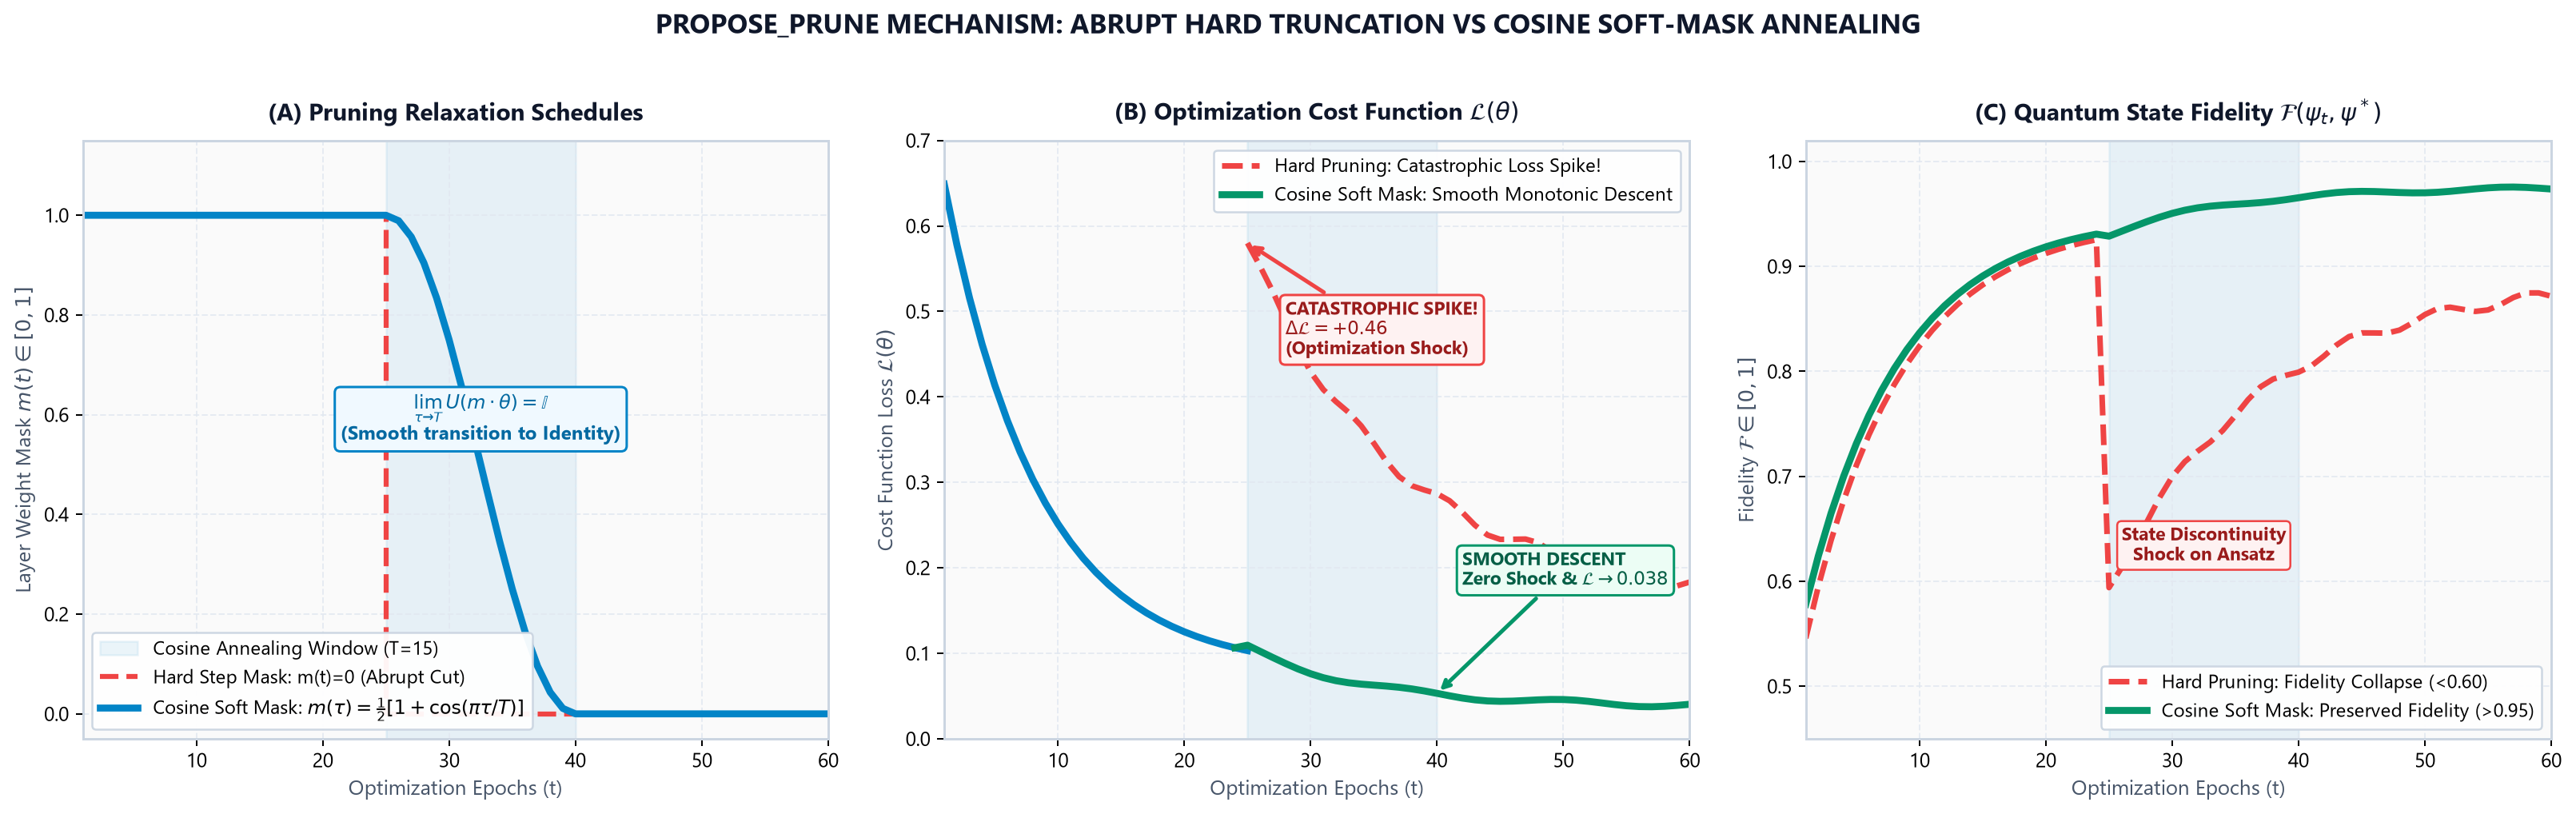

In [7]:
# Hiển thị biểu đồ đối chứng: Cắt tỉa đột ngột (Hard Prune) vs Hàm Soft Mask Cosine
from IPython.display import Image, display
display(Image(filename="figures/fig_prune_hard_vs_cosine_softmask.png"))

In [8]:
# Hoạt ảnh tương tác Plotly: Động lực học Hàm Mất Mát & Hàm Mặt Nạ Cosine m(tau)
# (Bấm nút 'Play Simulation' để quan sát trực tiếp cú sốc Loss Spike vs Sự êm dịu của Cosine Soft Mask)
from IPython.display import IFrame
IFrame(src="figures/anim_prune_hard_vs_cosine_softmask.html", width="100%", height=600)

---
## PHẦN 6: SIÊU HÀNH ĐỘNG 5 — `STOP_GROWTH` (PLOT ĐỘNG CHẬM RÃI 35 FRAMES)

* **Điều kiện kích hoạt**: Khi độ sâu mạch tăng đến ngưỡng nguy hiểm ($D=6$) và phương sai gradient $\operatorname{Var}(
abla \mathcal{L})$ tiệm cận biên vực thẳm Barren Plateau ($10^{-3}$).
* **Thao tác trên mạch**: Kích hoạt chốt an toàn xác định, khóa cứng vĩnh viễn độ sâu tối đa $D_{\max} = D(t) = 6$.
* **Ý nghĩa vật lý / Tối ưu hóa**: Ngăn chặn tuyệt đối việc rơi tự do vào thảm họa triệt tiêu độ dốc theo hàm mũ $\mathcal{O}(2^{-n})$. Trong khi mạch tĩnh (Static HEA) rơi xuống vực thẳm $10^{-5}$ khiến bộ tối ưu bị tê liệt hoàn toàn, Adaptive HEA chốt trần an toàn và chuyển sang giai đoạn tinh chỉnh trọng số ổn định.

*(Thời lượng phát hoạt họa: **~350ms / frame (~12 giây)** giúp người xem chứng kiến sự khác biệt rõ rệt giữa đường rơi tự do xuống vực và thềm an toàn Clamped)*

In [9]:
# Mô phỏng động tươi sáng, tốc độ chậm rãi cho STOP_GROWTH
depths = np.arange(1, 15)
var_grad_static = np.exp(-0.70 * depths)

var_grad_adaptive = np.copy(var_grad_static)
var_grad_adaptive[5:] = var_grad_static[5]

frames_stop = []
eval_depths = np.linspace(1, 14, 35)

for d_float in eval_depths:
    d_int = int(np.floor(d_float))
    sub_d = depths[:d_int]
    
    tr_abyss = go.Scatter(
        x=[0, 15, 15, 0], y=[1e-6, 1e-6, 0.005, 0.005],
        fill='toself', fillcolor='rgba(254, 226, 226, 0.45)',
        line=dict(width=0), mode='lines',
        name='Barren Plateau Abyss (Var &lt; 10⁻³)', hoverinfo='skip'
    )
    
    tr_ghost = go.Scatter(
        x=depths, y=var_grad_static, mode='lines',
        line=dict(color='#94A3B8', width=2.2, dash='dot'),
        name='Static HEA (Uncontrolled Growth &rarr; BP Collapse)'
    )
    
    if d_float <= 6.0:
        tr_active = go.Scatter(
            x=sub_d, y=var_grad_static[:d_int], mode='lines+markers',
            line=dict(color='#0284C7', width=3.5),
            marker=dict(size=8, color='#0284C7'),
            name='Controlled Depth Trajectory'
        )
        cur_d_display = d_int
        cur_var = var_grad_static[d_int - 1]
        status_hud = f"DEPTH D={cur_d_display} | Var(grad): {cur_var:.4f} | Status: Healthy Variance Corridor"
        badge_border = "#0284C7"
        badge_bg = "rgba(240, 249, 255, 0.95)"
        badge_font = "#0369A1"
    else:
        tr_active = go.Scatter(
            x=depths[:6], y=var_grad_static[:6], mode='lines+markers',
            line=dict(color='#0284C7', width=3.5),
            marker=dict(size=8, color='#0284C7'),
            name='Controlled Trajectory (D &le; 6)'
        )
        shelf_x = np.arange(6, d_int + 1)
        tr_clamped = go.Scatter(
            x=shelf_x, y=[var_grad_static[5]] * len(shelf_x), mode='lines+markers',
            line=dict(color='#059669', width=4),
            marker=dict(size=9, color='#059669', symbol='square'),
            name='STOP_GROWTH Clamped (D_max=6)'
        )
        cur_d_display = 6
        cur_var = var_grad_static[5]
        status_hud = f"DEPTH D={cur_d_display} (LOCKED) | Var(grad): {cur_var:.4f} | Action: STOP_GROWTH &mdash; Barren Plateau Prevented!"
        badge_border = "#059669"
        badge_bg = "rgba(236, 253, 245, 0.95)"
        badge_font = "#065F46"
        
    tr_head = go.Scatter(
        x=[6 if d_float > 6.0 else d_int],
        y=[var_grad_static[5] if d_float > 6.0 else var_grad_static[d_int - 1]],
        mode='markers',
        marker=dict(size=14, color='#059669' if d_float > 6.0 else '#0284C7',
                    line=dict(width=3, color='#FFFFFF')),
        showlegend=False
    )
    
    annot = [
        dict(
            x=0.5, y=1.07, xref="paper", yref="paper",
            text=f"<b>[TELEMETRY MONITOR]</b> {status_hud}",
            showarrow=False, font=dict(family="Segoe UI, sans-serif", size=13, color=badge_font),
            bgcolor=badge_bg, bordercolor=badge_border, borderwidth=1.8, borderpad=6
        )
    ]
    shapes = [
        dict(
            type="line", x0=0, x1=15, y0=0.005, y1=0.005,
            line=dict(color="#EF4444", width=1.8, dash="dash")
        )
    ]
    
    if d_float >= 6.0:
        annot.append(dict(
            x=6, y=var_grad_static[5], xref="x", yref="y",
            text="🛑 <b>STOP_GROWTH ENGAGED</b><br>Hard Clamp D_max = 6<br>BP Cliff Avoided!",
            showarrow=True, arrowhead=2, arrowcolor="#059669",
            font=dict(color="#065F46", size=10.5, family="Segoe UI, sans-serif"),
            bgcolor="rgba(236, 253, 245, 0.95)", bordercolor="#059669", borderwidth=1.2, borderpad=5
        ))
        shapes.append(dict(
            type="line", x0=6, x1=6, y0=1e-6, y1=1.0,
            line=dict(color="#059669", width=2.5, dash="dot")
        ))
        data_list = [tr_abyss, tr_ghost, tr_active, tr_clamped, tr_head]
    else:
        data_list = [tr_abyss, tr_ghost, tr_active, tr_head]
        
    f = go.Frame(
        data=data_list,
        layout=go.Layout(annotations=annot, shapes=shapes),
        name=f"d_{d_float:.1f}"
    )
    frames_stop.append(f)

fig_stop = go.Figure(
    data=frames_stop[0].data,
    layout=go.Layout(
        template="plotly_white",
        paper_bgcolor=LIGHT_BG, plot_bgcolor=PANEL_BG,
        title=dict(
            text="<b>ACTION 5: STOP_GROWTH</b> &mdash; Safeguarding Trainability Against Barren Plateau Collapse",
            font=dict(family="Segoe UI, sans-serif", size=17, color=TEXT_COLOR),
            x=0.03, y=0.96
        ),
        xaxis=dict(
            title="Circuit Depth D", range=[0.5, 14.5], dtick=1,
            gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=SUBTEXT_COLOR,
            linecolor=BORDER_COLOR, tickfont=dict(color=SUBTEXT_COLOR)
        ),
        yaxis=dict(
            title="Gradient Variance Var(&nabla;L) [Log Scale]",
            type="log", range=[-5.5, 0.2],
            gridcolor=GRID_COLOR, zerolinecolor=GRID_COLOR, color=SUBTEXT_COLOR,
            linecolor=BORDER_COLOR, tickfont=dict(color=SUBTEXT_COLOR)
        ),
        legend=dict(
            x=0.55, y=0.93, bgcolor="rgba(255, 255, 255, 0.95)",
            bordercolor=BORDER_COLOR, borderwidth=1, font=dict(color=TEXT_COLOR, size=11)
        ),
        updatemenus=[dict(
            type='buttons', showactive=False, x=0.03, y=1.17,
            buttons=[
                dict(label='▶ Play Simulation (Slow)', method='animate',
                     args=[None, dict(frame=dict(duration=350, redraw=True),
                                     transition=dict(duration=200, easing='cubic-in-out'),
                                     fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
            ],
            direction='left', pad=dict(r=10, t=10),
            bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=TEXT_COLOR, size=12)
        )],
        sliders=[dict(
            steps=[dict(method='animate', args=[[f.name]], label=f"{d:.1f}")
                   for d, f in zip(eval_depths, frames_stop)],
            active=0, transition=dict(duration=150),
            x=0.03, y=-0.12, len=0.94,
            currentvalue=dict(font=dict(size=12, color=TEXT_COLOR), prefix="Circuit Depth Scan: ", visible=True),
            bgcolor="#FFFFFF", bordercolor=BORDER_COLOR, font=dict(color=SUBTEXT_COLOR)
        )]
    ),
    frames=frames_stop
)
fig_stop.write_html("figures/anim_action_stop_growth.html")
fig_stop.show()